# 18_model_final_report_multitarget.ipynb — Informe final de modelado

Este notebook **no entrena modelos**. Su objetivo es consolidar todos los resultados de modelado de DeepWave Canarias.

Integra resultados de:

```text
15_model_training_multitarget_physical.ipynb
16_model_training_risk_modules.ipynb
17_model_surf_score.ipynb
```

Genera:

```text
gold/model_results/final_report_multitarget/
reports/tables/
reports/figures/
reports/model_summaries/
```

Incluye:

```text
- resumen de modelos entrenados
- métricas finales físicas
- métricas finales de riesgo
- métricas finales de surf score
- arquitectura final recomendada
- tablas y gráficos para la memoria
- informe ejecutivo en Markdown
```

Preparado para ejecutar en **Mac** con la estructura:

```text
deep-wave-canarias/
├── gold/
├── models/
├── notebooks/
└── reports/
```

## Celda 0 — Entorno local / Colab

In [1]:
import sys

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
else:
    print("Entorno local detectado. No se monta Google Drive.")

Entorno local detectado. No se monta Google Drive.


## Celda 1 — Imports, rutas y configuración

In [2]:
from pathlib import Path
import os
import sys
import json
import shutil
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------
# RUTAS — MAC FIRST
# ---------------------------------------------------------------------
LOCAL_BASE_DIR = Path.cwd().parent
RUNNING_IN_COLAB = "google.colab" in sys.modules

if RUNNING_IN_COLAB:
    BASE_DIR = Path("/content/drive/MyDrive/AI Projects/DeepWave Canarias")
else:
    BASE_DIR = Path(LOCAL_BASE_DIR).expanduser().resolve()

GOLD_DIR = BASE_DIR / "gold"
MODEL_RESULTS_DIR = GOLD_DIR / "model_results"

PHYSICAL_DIR = MODEL_RESULTS_DIR / "multitarget_physical"
RISK_DIR = MODEL_RESULTS_DIR / "risk_modules"
SURF_DIR = MODEL_RESULTS_DIR / "surf_score"

FINAL_DIR = MODEL_RESULTS_DIR / "final_report_multitarget"
FINAL_TABLES_DIR = FINAL_DIR / "tables"
FINAL_FIGURES_DIR = FINAL_DIR / "figures"

REPORTS_DIR = BASE_DIR / "reports"
REPORTS_TABLES_DIR = REPORTS_DIR / "tables"
REPORTS_FIGURES_DIR = REPORTS_DIR / "figures"
REPORTS_SUMMARIES_DIR = REPORTS_DIR / "model_summaries"

DOCS_DIR = BASE_DIR / "docs"

for d in [
    FINAL_DIR,
    FINAL_TABLES_DIR,
    FINAL_FIGURES_DIR,
    REPORTS_DIR,
    REPORTS_TABLES_DIR,
    REPORTS_FIGURES_DIR,
    REPORTS_SUMMARIES_DIR,
    DOCS_DIR,
]:
    d.mkdir(parents=True, exist_ok=True)

print("Sistema:", platform.platform())
print("BASE_DIR:", BASE_DIR)
print("PHYSICAL_DIR:", PHYSICAL_DIR, "existe:", PHYSICAL_DIR.exists())
print("RISK_DIR:", RISK_DIR, "existe:", RISK_DIR.exists())
print("SURF_DIR:", SURF_DIR, "existe:", SURF_DIR.exists())
print("FINAL_DIR:", FINAL_DIR)

if not GOLD_DIR.exists():
    raise FileNotFoundError(f"No existe GOLD_DIR: {GOLD_DIR}")

missing_result_dirs = [str(p) for p in [PHYSICAL_DIR, RISK_DIR, SURF_DIR] if not p.exists()]
if missing_result_dirs:
    print("AVISO: faltan algunos directorios de resultados:")
    for p in missing_result_dirs:
        print("-", p)
    print("El notebook seguirá y generará informe con lo disponible.")

Sistema: macOS-26.3.1-arm64-arm-64bit
BASE_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias
PHYSICAL_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/multitarget_physical existe: True
RISK_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/risk_modules existe: True
SURF_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/surf_score existe: True
FINAL_DIR: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget


## Celda 2 — Funciones auxiliares

In [3]:
def read_csv_safe(path, name=None):
    path = Path(path)
    if not path.exists():
        print(f"AVISO: no existe {path}")
        return pd.DataFrame()
    try:
        df = pd.read_csv(path)
        print(f"OK {name or path.name}: {df.shape}")
        return df
    except Exception as e:
        print(f"ERROR leyendo {path}: {e}")
        return pd.DataFrame()


def read_json_safe(path):
    path = Path(path)
    if not path.exists():
        print(f"AVISO: no existe {path}")
        return {}
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as e:
        print(f"ERROR leyendo {path}: {e}")
        return {}


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2, ensure_ascii=False, default=str)


def save_df(df, filename, index=False):
    if df is None or df.empty:
        print(f"SKIP guardado {filename}: dataframe vacío")
        return None

    path1 = FINAL_TABLES_DIR / filename
    path2 = REPORTS_TABLES_DIR / filename

    df.to_csv(path1, index=index)
    df.to_csv(path2, index=index)

    print("Guardado:", path1)
    print("Copia reports:", path2)
    return path1


def copy_if_exists(src, dst_dir):
    src = Path(src)
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    if src.exists():
        dst = dst_dir / src.name
        shutil.copy2(src, dst)
        return dst
    return None


def clean_metric_value(x):
    try:
        if pd.isna(x):
            return np.nan
        return float(x)
    except Exception:
        return np.nan


def format_float(x, nd=4):
    try:
        if pd.isna(x):
            return "NA"
        return f"{float(x):.{nd}f}"
    except Exception:
        return "NA"


def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def make_plot_line(df, x_col, y_col, group_col, title, ylabel, out_name):
    if df is None or df.empty:
        print("SKIP plot vacío:", out_name)
        return None
    if x_col not in df.columns or y_col not in df.columns or group_col not in df.columns:
        print("SKIP plot faltan columnas:", out_name)
        return None

    plt.figure(figsize=(10, 5))

    for group_value in sorted(df[group_col].dropna().unique()):
        data = df[df[group_col] == group_value].sort_values(x_col)
        if data.empty:
            continue
        plt.plot(data[x_col], data[y_col], marker="o", label=str(group_value))

    plt.xlabel("Horizonte predictivo (h)")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    out1 = FINAL_FIGURES_DIR / out_name
    out2 = REPORTS_FIGURES_DIR / out_name

    plt.savefig(out1, dpi=160)
    plt.savefig(out2, dpi=160)
    plt.show()

    print("Figura guardada:", out1)
    print("Copia reports:", out2)

    return out1


def dataframe_to_markdown_table(df, max_rows=20):
    if df is None or df.empty:
        return "_No disponible._"

    small = df.head(max_rows).copy()
    return small.to_markdown(index=False)


def best_by_group(df, group_cols, score_col, ascending=False):
    if df is None or df.empty or score_col not in df.columns:
        return pd.DataFrame()
    return (
        df.sort_values(score_col, ascending=ascending)
        .groupby(group_cols, as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

## Celda 3 — Cargar resultados de notebooks 15, 16 y 17

In [4]:
# ---------------------------------------------------------------------
# Notebook 15 — físicos
# ---------------------------------------------------------------------
physical_scalar = read_csv_safe(PHYSICAL_DIR / "metrics_scalar_regression.csv", "physical_scalar")
physical_direction = read_csv_safe(PHYSICAL_DIR / "metrics_direction_regression.csv", "physical_direction")
physical_scalar_improvement = read_csv_safe(PHYSICAL_DIR / "test_improvement_scalar_vs_persistence.csv", "physical_scalar_improvement")
physical_direction_improvement = read_csv_safe(PHYSICAL_DIR / "test_improvement_direction_vs_persistence.csv", "physical_direction_improvement")
physical_training_summary = read_csv_safe(PHYSICAL_DIR / "training_summary.csv", "physical_training_summary")
physical_feature_importance_top = read_csv_safe(PHYSICAL_DIR / "feature_importance_top30.csv", "physical_feature_importance_top")
physical_summary_json = read_json_safe(PHYSICAL_DIR / "multitarget_physical_summary.json")

# ---------------------------------------------------------------------
# Notebook 16 — riesgos
# ---------------------------------------------------------------------
risk_metrics_scored = read_csv_safe(RISK_DIR / "test_metrics_risk_modules_scored.csv", "risk_metrics_scored")
risk_recommendations = read_csv_safe(RISK_DIR / "recommendation_by_risk_module_horizon.csv", "risk_recommendations")
risk_metrics_all = read_csv_safe(RISK_DIR / "metrics_risk_classification_with_physical_derived.csv", "risk_metrics_all")
if risk_metrics_all.empty:
    risk_metrics_all = read_csv_safe(RISK_DIR / "metrics_risk_classification.csv", "risk_metrics_all_fallback")
risk_training_summary = read_csv_safe(RISK_DIR / "training_summary.csv", "risk_training_summary")
risk_feature_importance_top = read_csv_safe(RISK_DIR / "feature_importance_top30.csv", "risk_feature_importance_top")
risk_summary_json = read_json_safe(RISK_DIR / "risk_modules_summary.json")

# ---------------------------------------------------------------------
# Notebook 17 — surf
# ---------------------------------------------------------------------
surf_metrics_scored = read_csv_safe(SURF_DIR / "test_metrics_surf_score_scored.csv", "surf_metrics_scored")
surf_recommendations = read_csv_safe(SURF_DIR / "recommendation_by_horizon.csv", "surf_recommendations")
surf_metrics_all = read_csv_safe(SURF_DIR / "metrics_surf_score.csv", "surf_metrics_all")
surf_training_summary = read_csv_safe(SURF_DIR / "training_summary.csv", "surf_training_summary")
surf_feature_importance_top = read_csv_safe(SURF_DIR / "feature_importance_top30.csv", "surf_feature_importance_top")
surf_summary_json = read_json_safe(SURF_DIR / "surf_score_summary.json")

print("\nCarga completada.")

OK physical_scalar: (360, 15)
OK physical_direction: (120, 21)
OK physical_scalar_improvement: (60, 10)
OK physical_direction_improvement: (20, 7)
OK physical_training_summary: (80, 14)
OK physical_feature_importance_top: (3000, 6)
OK risk_metrics_scored: (45, 27)
OK risk_recommendations: (15, 9)
OK risk_metrics_all: (120, 26)
OK risk_training_summary: (15, 11)
OK risk_feature_importance_top: (450, 5)
OK surf_metrics_scored: (15, 36)
OK surf_recommendations: (5, 8)
OK surf_metrics_all: (40, 35)
OK surf_training_summary: (5, 8)
OK surf_feature_importance_top: (150, 4)

Carga completada.


## Celda 4 — Resumen de modelos entrenados

In [5]:
summary_rows = []

# Físicos
if not physical_training_summary.empty:
    n_physical_rows = len(physical_training_summary)
    n_scalar = int((physical_training_summary.get("target_type", pd.Series(dtype=str)) == "scalar").sum()) if "target_type" in physical_training_summary.columns else np.nan
    n_direction = int((physical_training_summary.get("target_type", pd.Series(dtype=str)) == "direction").sum()) if "target_type" in physical_training_summary.columns else np.nan
else:
    n_physical_rows = 0
    n_scalar = np.nan
    n_direction = np.nan

summary_rows.append({
    "block": "physical_multitarget",
    "notebook": "15_model_training_multitarget_physical.ipynb",
    "main_output": str(PHYSICAL_DIR),
    "models_or_entries": n_physical_rows,
    "details": f"scalar_entries={n_scalar}, direction_entries={n_direction}",
    "status": "OK" if n_physical_rows > 0 else "missing_or_empty",
})

# Riesgo
if not risk_training_summary.empty:
    n_risk = len(risk_training_summary)
    details = risk_training_summary["model"].value_counts().to_dict() if "model" in risk_training_summary.columns else {}
else:
    n_risk = 0
    details = {}

summary_rows.append({
    "block": "risk_modules",
    "notebook": "16_model_training_risk_modules.ipynb",
    "main_output": str(RISK_DIR),
    "models_or_entries": n_risk,
    "details": json.dumps(details, ensure_ascii=False),
    "status": "OK" if n_risk > 0 else "missing_or_empty",
})

# Surf
if not surf_training_summary.empty:
    n_surf = len(surf_training_summary)
else:
    n_surf = 0

summary_rows.append({
    "block": "surf_score",
    "notebook": "17_model_surf_score.ipynb",
    "main_output": str(SURF_DIR),
    "models_or_entries": n_surf,
    "details": "DirectLGBMSurfScore entries" if n_surf else "rule-based modules evaluated",
    "status": "OK" if (n_surf > 0 or not surf_metrics_scored.empty) else "missing_or_empty",
})

modeling_status = pd.DataFrame(summary_rows)
save_df(modeling_status, "final_modeling_status.csv")
display(modeling_status)

final_counts = {
    "physical_training_entries": int(n_physical_rows),
    "risk_training_entries": int(n_risk),
    "surf_training_entries": int(n_surf),
    "physical_results_available": not physical_scalar.empty or not physical_direction.empty,
    "risk_results_available": not risk_metrics_scored.empty or not risk_recommendations.empty,
    "surf_results_available": not surf_metrics_scored.empty or not surf_recommendations.empty,
}

save_json(final_counts, FINAL_DIR / "final_counts.json")
display(pd.DataFrame([final_counts]))

Guardado: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/tables/final_modeling_status.csv
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/tables/final_modeling_status.csv


,block,notebook,main_output,models_or_entries,details,status
0,physical_multitarget,15_model_training_multitarget_physical.ipynb,/Users/rauljimenez/Development/Projects/AI-Pro...,80,"scalar_entries=60, direction_entries=20",OK
1,risk_modules,16_model_training_risk_modules.ipynb,/Users/rauljimenez/Development/Projects/AI-Pro...,15,"{""LightGBMClassifier"": 15}",OK
2,surf_score,17_model_surf_score.ipynb,/Users/rauljimenez/Development/Projects/AI-Pro...,5,DirectLGBMSurfScore entries,OK


,physical_training_entries,risk_training_entries,surf_training_entries,physical_results_available,risk_results_available,surf_results_available
0,80,15,5,True,True,True


## Celda 5 — Informe físico final

Guardado: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/tables/final_physical_scalar_improvement.csv
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/tables/final_physical_scalar_improvement.csv


,target_name,horizon_hours,mae_model,mae_persistence,mae_improvement_pct,rmse_model,rmse_persistence,rmse_improvement_pct,r2_model,corr_model,recommended_use
0,current_speed,3,0.069078,0.054386,-27.014649,0.091994,0.069817,-31.764960,0.430773,0.773959,not_priority
1,current_speed,6,0.076098,0.080742,5.752595,0.098693,0.103315,4.473605,0.345011,0.661373,not_priority
2,current_speed,12,0.078744,0.084032,6.293204,0.103817,0.109234,4.959039,0.275650,0.664425,not_priority
3,current_speed,24,0.084286,0.055324,-52.349571,0.111562,0.077002,-44.882319,0.164922,0.632654,not_priority
4,current_speed,48,0.072258,0.076051,4.987503,0.101442,0.102818,1.338604,0.311978,0.559780,not_priority
5,daily_tidal_range,3,0.009393,0.020512,54.206189,0.022417,0.068497,67.272869,0.997865,0.998932,main
6,daily_tidal_range,6,0.015916,0.040994,61.173976,0.032702,0.096793,66.214685,0.995459,0.997727,main
7,daily_tidal_range,12,0.031622,0.082040,61.455159,0.050204,0.136883,63.323202,0.989311,0.994665,main
8,daily_tidal_range,24,0.055623,0.164146,66.113977,0.072413,0.193453,62.567931,0.977793,0.988914,main
9,daily_tidal_range,48,0.092723,0.313401,70.414015,0.117432,0.369496,68.218265,0.941688,0.971219,main


Guardado: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/tables/final_physical_direction_improvement.csv
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/tables/final_physical_direction_improvement.csv


,target_name,horizon_hours,angular_mae_model,angular_mae_persistence,angular_mae_improvement_pct,within_30deg_model,within_30deg_persistence,recommended_use
0,current_direction,3,22.013200,30.738816,28.386311,78.258854,65.152449,experimental
1,current_direction,6,35.531911,50.001346,28.938091,60.750970,45.064779,experimental
2,current_direction,12,41.381426,52.852010,21.703212,54.528641,45.683152,experimental
3,current_direction,24,26.523599,26.831930,1.149121,72.626629,72.313961,experimental
4,current_direction,48,37.596349,38.836898,3.194253,58.553900,57.403211,experimental
5,swell_direction,3,10.296784,9.530585,-8.039371,91.367367,91.430804,secondary
6,swell_direction,6,12.787972,12.968181,1.389621,88.596759,87.859066,secondary
7,swell_direction,12,15.505177,16.836327,7.906414,85.286450,83.504918,secondary
8,swell_direction,24,19.493135,21.520455,9.420431,80.130605,77.643798,secondary
9,swell_direction,48,24.414024,28.198382,13.420480,73.220255,68.478395,secondary


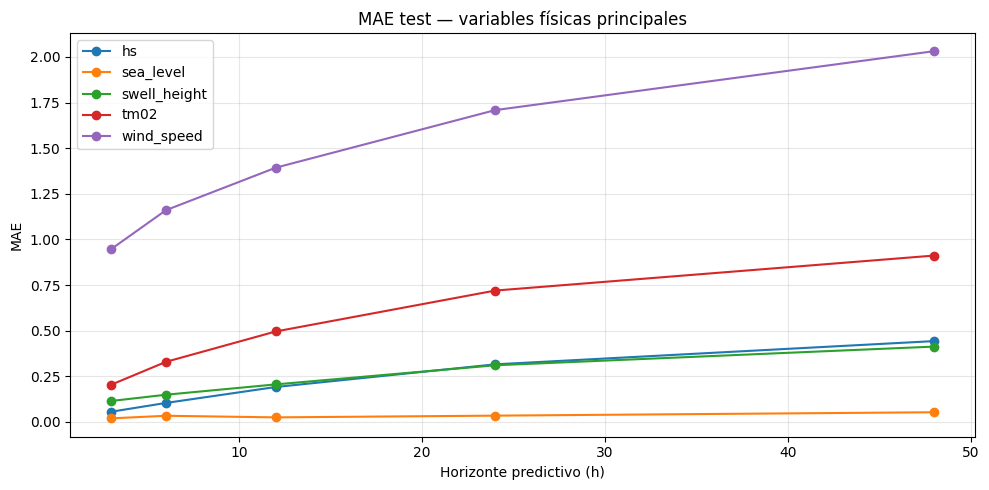

Figura guardada: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/figures/final_physical_scalar_mae.png
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/figures/final_physical_scalar_mae.png


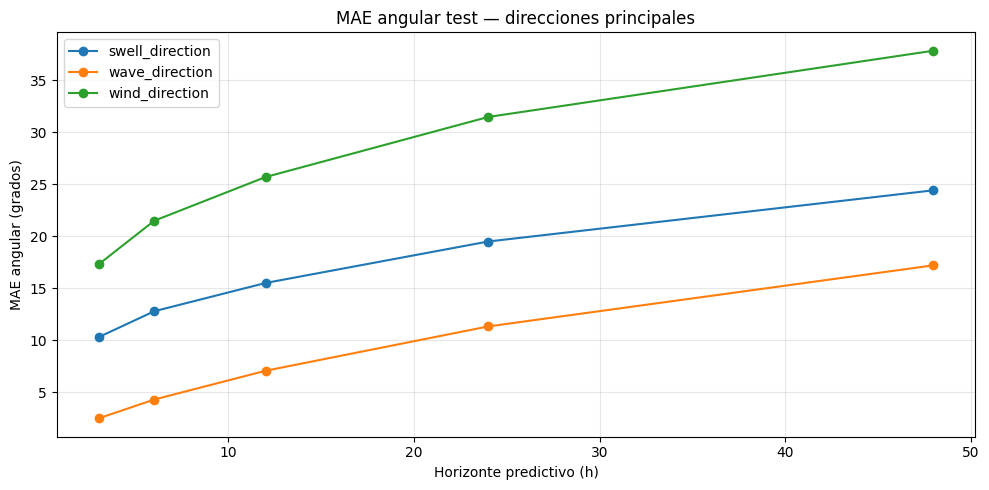

Figura guardada: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/figures/final_physical_direction_angular_mae.png
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/figures/final_physical_direction_angular_mae.png


In [6]:
# Métricas físicas escalares test.
if not physical_scalar.empty:
    physical_scalar_test = physical_scalar[
        (physical_scalar["split"] == "test")
        & (physical_scalar["model"] == "LightGBMRegressor")
    ].copy()
else:
    physical_scalar_test = pd.DataFrame()

# Métricas direccionales test.
if not physical_direction.empty:
    physical_direction_test = physical_direction[
        (physical_direction["split"] == "test")
        & (physical_direction["model"] == "LightGBMRegressor_sin_cos")
    ].copy()
else:
    physical_direction_test = pd.DataFrame()

# Tabla compacta de escalares recomendados.
if not physical_scalar_improvement.empty:
    physical_scalar_final = physical_scalar_improvement.copy()
    physical_scalar_final["recommended_use"] = "review"

    strong_targets = ["hs", "tm02", "swell_height", "swell_period", "wind_speed", "sea_level", "daily_tidal_range"]
    secondary_targets = ["tp", "wind_wave_height"]
    weak_targets = ["current_speed", "sea_surface_temperature", "sea_surface_salinity"]

    physical_scalar_final.loc[physical_scalar_final["target_name"].isin(strong_targets), "recommended_use"] = "main"
    physical_scalar_final.loc[physical_scalar_final["target_name"].isin(secondary_targets), "recommended_use"] = "secondary"
    physical_scalar_final.loc[physical_scalar_final["target_name"].isin(weak_targets), "recommended_use"] = "not_priority"

    save_df(physical_scalar_final, "final_physical_scalar_improvement.csv")
    display(physical_scalar_final)
else:
    physical_scalar_final = physical_scalar_test.copy()
    save_df(physical_scalar_final, "final_physical_scalar_test.csv")
    display(physical_scalar_final)

# Tabla compacta de direcciones.
if not physical_direction_improvement.empty:
    physical_direction_final = physical_direction_improvement.copy()
    physical_direction_final["recommended_use"] = "review"

    physical_direction_final.loc[physical_direction_final["target_name"].isin(["wave_direction", "wind_direction"]), "recommended_use"] = "main"
    physical_direction_final.loc[physical_direction_final["target_name"].isin(["swell_direction"]), "recommended_use"] = "secondary"
    physical_direction_final.loc[physical_direction_final["target_name"].isin(["current_direction"]), "recommended_use"] = "experimental"

    save_df(physical_direction_final, "final_physical_direction_improvement.csv")
    display(physical_direction_final)
else:
    physical_direction_final = physical_direction_test.copy()
    save_df(physical_direction_final, "final_physical_direction_test.csv")
    display(physical_direction_final)

# Plots principales.
if not physical_scalar_test.empty:
    core_scalar_plot = physical_scalar_test[physical_scalar_test["target_name"].isin(["hs", "tm02", "swell_height", "wind_speed", "sea_level"])].copy()
    make_plot_line(
        core_scalar_plot,
        "horizon_hours",
        "mae",
        "target_name",
        "MAE test — variables físicas principales",
        "MAE",
        "final_physical_scalar_mae.png",
    )

if not physical_direction_test.empty and "angular_mae" in physical_direction_test.columns:
    core_dir_plot = physical_direction_test[physical_direction_test["target_name"].isin(["wave_direction", "swell_direction", "wind_direction"])].copy()
    make_plot_line(
        core_dir_plot,
        "horizon_hours",
        "angular_mae",
        "target_name",
        "MAE angular test — direcciones principales",
        "MAE angular (grados)",
        "final_physical_direction_angular_mae.png",
    )

## Celda 6 — Informe de riesgo final

Guardado: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/tables/final_risk_recommendations.csv
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/tables/final_risk_recommendations.csv


,risk_module,horizon_hours,recommended_model,recommended_score,recommended_macro_f1,recommended_balanced_accuracy,recommended_recall_class_2,recommended_recall_class_3,all_models_ranked
0,beach,3,PhysicalDerivedRisk_LGBMPhysical,0.690130,0.773451,0.772548,0.722981,0.471353,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
1,beach,6,PhysicalDerivedRisk_LGBMPhysical,0.654465,0.736513,0.733088,0.684337,0.443052,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
2,beach,12,PhysicalDerivedRisk_LGBMPhysical,0.594626,0.673901,0.665428,0.638285,0.386644,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
3,beach,24,PersistenceRisk,0.517329,0.575733,0.570415,0.496512,0.394968,"[{""model"": ""PersistenceRisk"", ""security_score""..."
4,beach,48,PersistenceRisk,0.428847,0.476285,0.471018,0.404267,0.335009,"[{""model"": ""PersistenceRisk"", ""security_score""..."
5,general,3,PhysicalDerivedRisk_LGBMPhysical,0.937471,0.945097,0.941164,0.926040,0.929959,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
6,general,6,PhysicalDerivedRisk_LGBMPhysical,0.877195,0.895858,0.885385,0.865059,0.850159,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
7,general,12,PhysicalDerivedRisk_LGBMPhysical,0.759051,0.802272,0.777760,0.763689,0.677050,"[{""model"": ""PhysicalDerivedRisk_LGBMPhysical"",..."
8,general,24,PersistenceRisk,0.573849,0.620085,0.619793,0.533913,0.487135,"[{""model"": ""PersistenceRisk"", ""security_score""..."
9,general,48,PersistenceRisk,0.440417,0.493495,0.492963,0.398100,0.338950,"[{""model"": ""PersistenceRisk"", ""security_score""..."


Guardado: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/tables/final_risk_test_metrics_scored.csv
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/tables/final_risk_test_metrics_scored.csv


,risk_module,horizon_hours,target_col,split,model,n,accuracy,balanced_accuracy,macro_f1,weighted_f1,...,support_class_1,precision_class_2,recall_class_2,f1_class_2,support_class_2,precision_class_3,recall_class_3,f1_class_3,support_class_3,security_score
35,beach,3,target_risk_beach_3h,test,PhysicalDerivedRisk_LGBMPhysical,197043,0.777414,0.772548,0.773451,0.770560,...,74981,0.556379,0.722981,0.628832,47051,0.980583,0.471353,0.636668,48749,0.690130
10,beach,3,target_risk_beach_3h,test,PersistenceRisk,197043,0.760078,0.756160,0.758604,0.755596,...,74981,0.545770,0.702004,0.614106,47051,0.942327,0.489015,0.643888,48749,0.682106
11,beach,3,target_risk_beach_3h,test,LightGBMClassifier,39777,0.399930,0.408983,0.394800,0.408953,...,13127,0.314408,0.452535,0.371033,6510,0.262887,0.423764,0.324479,7221,0.414247
36,beach,6,target_risk_beach_6h,test,PhysicalDerivedRisk_LGBMPhysical,196830,0.740807,0.733088,0.736513,0.734416,...,74897,0.520256,0.684337,0.591121,47009,0.966008,0.443052,0.607486,48685,0.654465
12,beach,6,target_risk_beach_6h,test,PersistenceRisk,196830,0.715353,0.711384,0.714822,0.712261,...,74897,0.507036,0.652237,0.570543,47009,0.906733,0.471069,0.620022,48685,0.643637
13,beach,6,target_risk_beach_6h,test,LightGBMClassifier,39522,0.375791,0.379666,0.369503,0.387424,...,13024,0.267560,0.385070,0.315736,6430,0.249306,0.400697,0.307372,7175,0.382177
37,beach,12,target_risk_beach_12h,test,PhysicalDerivedRisk_LGBMPhysical,196404,0.679599,0.665428,0.673901,0.673722,...,74749,0.462599,0.638285,0.536424,46885,0.943629,0.386644,0.548532,48577,0.594626
14,beach,12,target_risk_beach_12h,test,PersistenceRisk,196404,0.652069,0.648704,0.653360,0.650754,...,74749,0.451738,0.581956,0.508645,46885,0.851104,0.442679,0.582425,48577,0.588815
15,beach,12,target_risk_beach_12h,test,LightGBMClassifier,39012,0.362222,0.358205,0.351210,0.376886,...,12949,0.208975,0.279717,0.239225,6360,0.242216,0.417337,0.306528,6841,0.358766
16,beach,24,target_risk_beach_24h,test,PersistenceRisk,195552,0.571904,0.570415,0.575733,0.571704,...,74308,0.385647,0.496512,0.434113,46734,0.759593,0.394968,0.519704,48414,0.517329


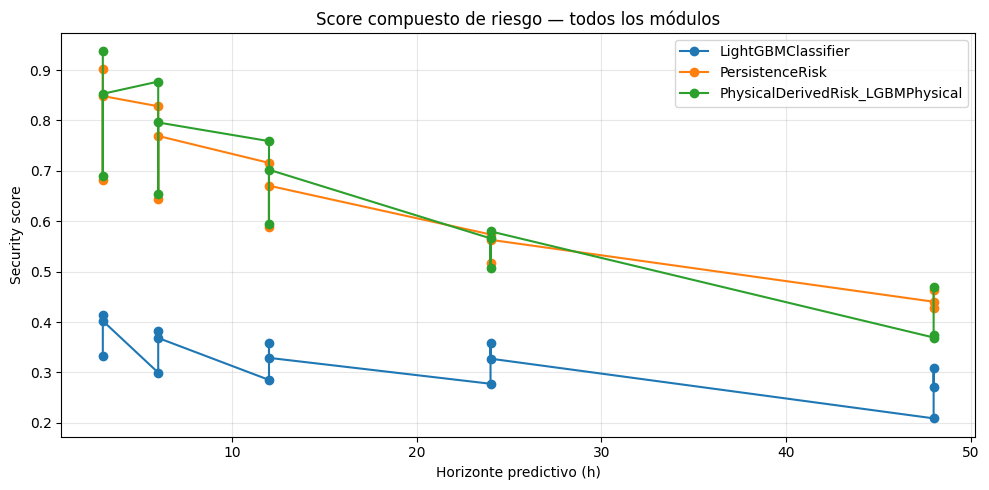

Figura guardada: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/figures/final_risk_security_score_by_model.png
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/figures/final_risk_security_score_by_model.png


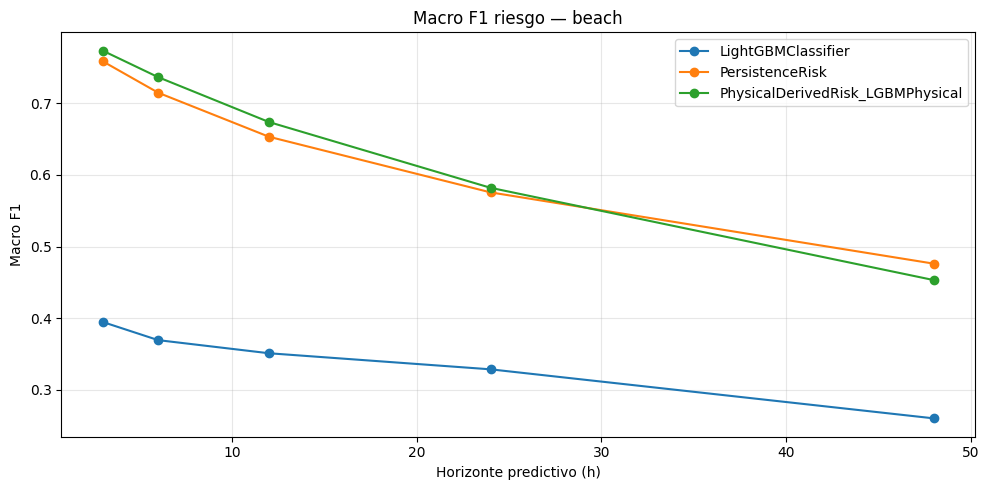

Figura guardada: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/figures/final_risk_macro_f1_beach.png
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/figures/final_risk_macro_f1_beach.png


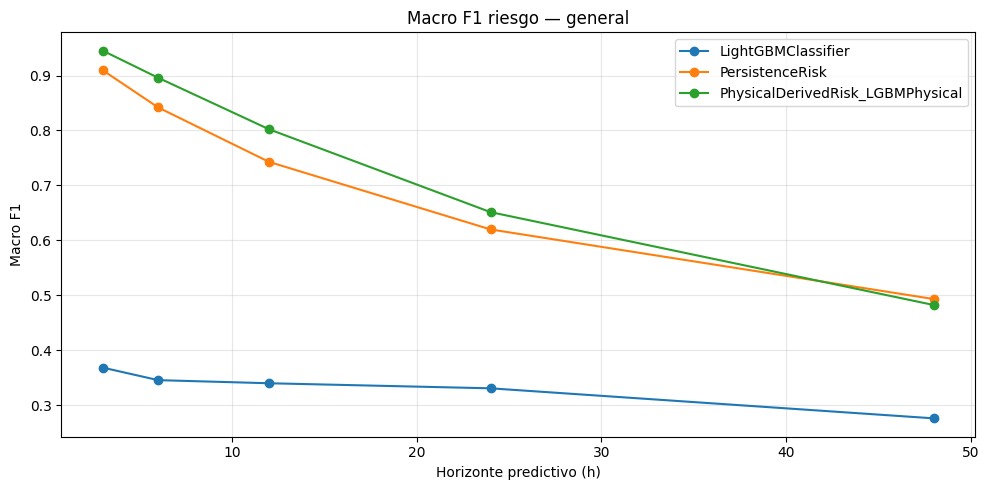

Figura guardada: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/figures/final_risk_macro_f1_general.png
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/figures/final_risk_macro_f1_general.png


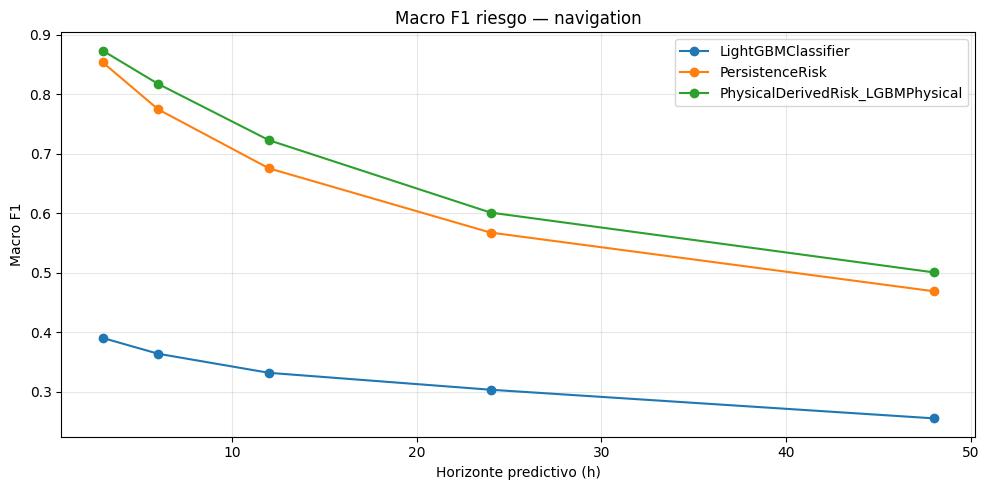

Figura guardada: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/figures/final_risk_macro_f1_navigation.png
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/figures/final_risk_macro_f1_navigation.png


In [7]:
if not risk_recommendations.empty:
    risk_final_recommendations = risk_recommendations.copy()
    save_df(risk_final_recommendations, "final_risk_recommendations.csv")
    display(risk_final_recommendations)
else:
    risk_final_recommendations = pd.DataFrame()

if not risk_metrics_scored.empty:
    save_df(risk_metrics_scored, "final_risk_test_metrics_scored.csv")
    display(risk_metrics_scored.sort_values(["risk_module", "horizon_hours", "security_score"], ascending=[True, True, False]).head(80))

    make_plot_line(
        risk_metrics_scored,
        "horizon_hours",
        "security_score",
        "model",
        "Score compuesto de riesgo — todos los módulos",
        "Security score",
        "final_risk_security_score_by_model.png",
    )

    # Plot por módulo.
    for module in sorted(risk_metrics_scored["risk_module"].dropna().unique()):
        sub = risk_metrics_scored[risk_metrics_scored["risk_module"] == module].copy()
        make_plot_line(
            sub,
            "horizon_hours",
            "macro_f1",
            "model",
            f"Macro F1 riesgo — {module}",
            "Macro F1",
            f"final_risk_macro_f1_{module}.png",
        )
else:
    print("No hay risk_metrics_scored.")

## Celda 7 — Informe de surf score final

Guardado: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/tables/final_surf_recommendations.csv
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/tables/final_surf_recommendations.csv


,horizon_hours,recommended_model,recommended_score,recommended_mae,recommended_rmse,recommended_quality_macro_f1,recommended_quality_balanced_accuracy,all_models_ranked
0,3,CurrentConditionsSurfScore,0.775391,0.579702,1.051352,0.748335,0.752145,"[{""model"": ""CurrentConditionsSurfScore"", ""surf..."
1,6,DirectLGBMSurfScore,0.698044,0.723377,1.060879,0.652173,0.641450,"[{""model"": ""DirectLGBMSurfScore"", ""surf_module..."
2,12,PhysicalDerivedSurfScore,0.602685,0.960601,1.469307,0.547635,0.525511,"[{""model"": ""PhysicalDerivedSurfScore"", ""surf_m..."
3,24,PhysicalDerivedSurfScore,0.489591,1.276750,1.845385,0.425966,0.410078,"[{""model"": ""PhysicalDerivedSurfScore"", ""surf_m..."
4,48,PhysicalDerivedSurfScore,0.387827,1.565356,2.161872,0.311439,0.318136,"[{""model"": ""PhysicalDerivedSurfScore"", ""surf_m..."


Guardado: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/tables/final_surf_test_metrics_scored.csv
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/tables/final_surf_test_metrics_scored.csv


,model,horizon_hours,split,n,mae,rmse,r2,bias,corr,n_quality,...,quality_precision_very_good,quality_recall_very_good,quality_f1_very_good,quality_support_very_good,quality_precision_epic,quality_recall_epic,quality_f1_epic,quality_support_epic,best_iteration,surf_module_score
0,CurrentConditionsSurfScore,3,test,197256,0.579702,1.051352,0.790348,0.061757,0.893943,197256,...,0.717612,0.725072,0.721322,45019,0.823342,0.817584,0.820453,50763,NaN,0.775391
10,DirectLGBMSurfScore,3,test,197256,0.525273,0.823178,0.871474,-0.000614,0.933556,197256,...,0.633740,0.757591,0.690153,45019,0.860827,0.715364,0.781383,50763,2496.0,0.772385
5,PhysicalDerivedSurfScore,3,test,197043,0.564786,0.950408,0.827976,-0.174368,0.913499,197043,...,0.664298,0.533664,0.591858,45019,0.737480,0.836633,0.783934,50763,NaN,0.759874
11,DirectLGBMSurfScore,6,test,197256,0.723377,1.060879,0.787406,0.009571,0.887438,197256,...,0.528397,0.714263,0.607430,44926,0.830433,0.612752,0.705176,50704,1218.0,0.698044
6,PhysicalDerivedSurfScore,6,test,196830,0.724116,1.169163,0.739694,-0.123093,0.863488,196830,...,0.571262,0.478654,0.520873,44926,0.699729,0.788892,0.741640,50704,NaN,0.693502
1,CurrentConditionsSurfScore,6,test,197256,0.826041,1.359972,0.650636,0.067836,0.822678,197256,...,0.610922,0.618551,0.614712,44926,0.746965,0.742604,0.744778,50704,NaN,0.684188
7,PhysicalDerivedSurfScore,12,test,196404,0.960601,1.469307,0.589016,-0.027548,0.774974,196404,...,0.464595,0.428230,0.445672,44754,0.639397,0.715042,0.675107,50597,NaN,0.602685
12,DirectLGBMSurfScore,12,test,197256,0.988373,1.374603,0.646022,0.012317,0.803833,197256,...,0.423276,0.680766,0.521995,44754,0.794729,0.454138,0.577990,50597,370.0,0.597950
2,CurrentConditionsSurfScore,12,test,197256,1.151647,1.750517,0.425944,0.079904,0.707281,197256,...,0.489898,0.497922,0.493878,44754,0.643906,0.641500,0.642701,50597,NaN,0.572970
8,PhysicalDerivedSurfScore,24,test,195552,1.276750,1.845385,0.352063,0.124484,0.626317,195552,...,0.367143,0.394549,0.380353,44504,0.553070,0.609197,0.579778,50363,NaN,0.489591


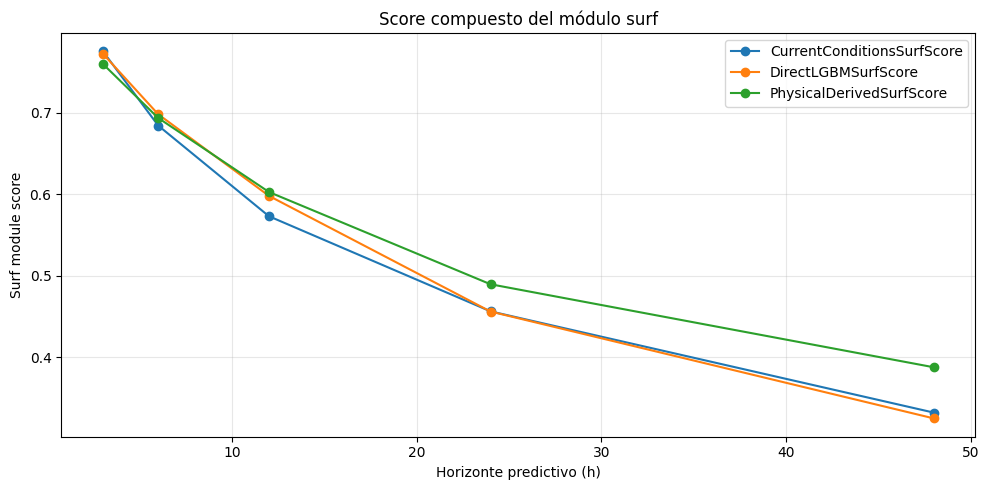

Figura guardada: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/figures/final_surf_module_score.png
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/figures/final_surf_module_score.png


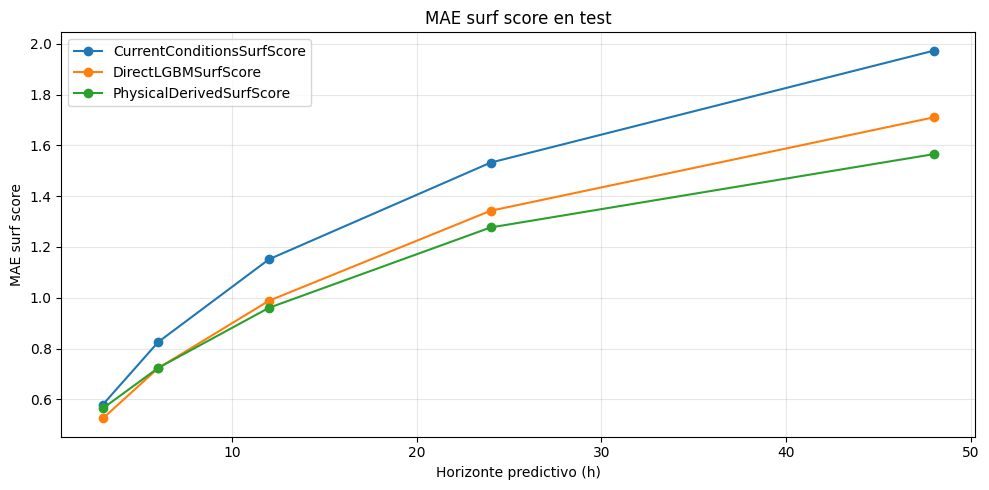

Figura guardada: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/figures/final_surf_score_mae.png
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/figures/final_surf_score_mae.png


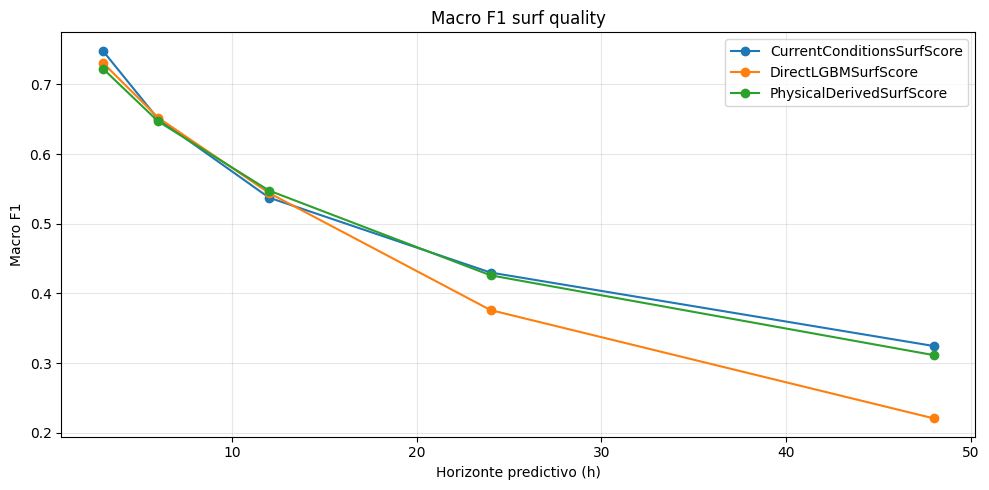

Figura guardada: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/figures/final_surf_quality_macro_f1.png
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/figures/final_surf_quality_macro_f1.png


In [8]:
if not surf_recommendations.empty:
    surf_final_recommendations = surf_recommendations.copy()
    save_df(surf_final_recommendations, "final_surf_recommendations.csv")
    display(surf_final_recommendations)
else:
    surf_final_recommendations = pd.DataFrame()

if not surf_metrics_scored.empty:
    save_df(surf_metrics_scored, "final_surf_test_metrics_scored.csv")
    display(surf_metrics_scored.sort_values(["horizon_hours", "surf_module_score"], ascending=[True, False]))

    make_plot_line(
        surf_metrics_scored,
        "horizon_hours",
        "surf_module_score",
        "model",
        "Score compuesto del módulo surf",
        "Surf module score",
        "final_surf_module_score.png",
    )

    make_plot_line(
        surf_metrics_scored,
        "horizon_hours",
        "mae",
        "model",
        "MAE surf score en test",
        "MAE surf score",
        "final_surf_score_mae.png",
    )

    make_plot_line(
        surf_metrics_scored,
        "horizon_hours",
        "quality_macro_f1",
        "model",
        "Macro F1 surf quality",
        "Macro F1",
        "final_surf_quality_macro_f1.png",
    )
else:
    print("No hay surf_metrics_scored.")

## Celda 8 — Decisión de arquitectura final

In [9]:
# Decisiones basadas en análisis de notebooks anteriores.
# Si existen tablas de recomendaciones, se incorporan; si no, se usan decisiones por defecto.

physical_main_targets = [
    "hs",
    "tm02",
    "swell_height",
    "swell_period",
    "wave_direction",
    "wind_speed",
    "wind_direction",
    "sea_level",
    "daily_tidal_range",
]

physical_secondary_targets = [
    "tp",
    "swell_direction",
    "wind_wave_height",
]

physical_not_priority = [
    "sea_surface_salinity",
    "current_speed",
    "sea_surface_temperature",
]

# Riesgo: usar recomendaciones automáticas si existen.
risk_architecture_rows = []

if not risk_final_recommendations.empty:
    for _, row in risk_final_recommendations.iterrows():
        risk_architecture_rows.append({
            "module": f"risk_{row['risk_module']}",
            "horizon_hours": int(row["horizon_hours"]),
            "selected_method": row["recommended_model"],
            "reason": "best_security_score_from_notebook_16",
        })
else:
    for module in ["general", "beach", "navigation"]:
        for h in [3, 6, 12]:
            risk_architecture_rows.append({
                "module": f"risk_{module}",
                "horizon_hours": h,
                "selected_method": "PhysicalDerivedRisk_LGBMPhysical",
                "reason": "default_interpretable_short_medium_horizon",
            })
        for h in [24, 48]:
            risk_architecture_rows.append({
                "module": f"risk_{module}",
                "horizon_hours": h,
                "selected_method": "PersistenceRisk_or_PhysicalDerived_with_high_uncertainty",
                "reason": "default_long_horizon_stability",
            })

risk_architecture = pd.DataFrame(risk_architecture_rows)

# Surf: preferimos PhysicalDerived como solución final por interpretabilidad.
surf_architecture_rows = []

for h in [3, 6, 12, 24, 48]:
    selected = "PhysicalDerivedSurfScore"
    reason = "interpretable_and_consistent_with_physical_forecast"

    # Si el notebook recomienda otro método, lo anotamos pero mantenemos decisión final.
    notebook_reco = None
    if not surf_final_recommendations.empty:
        sub = surf_final_recommendations[surf_final_recommendations["horizon_hours"] == h]
        if not sub.empty:
            notebook_reco = sub.iloc[0].get("recommended_model", None)

    surf_architecture_rows.append({
        "module": "surf_score",
        "horizon_hours": h,
        "selected_method": selected,
        "notebook_recommended_model": notebook_reco,
        "reason": reason,
    })

surf_architecture = pd.DataFrame(surf_architecture_rows)

final_architecture = {
    "physical_forecast": {
        "main_model_family": "LightGBMRegressor per target and horizon",
        "main_targets": physical_main_targets,
        "secondary_targets": physical_secondary_targets,
        "not_priority_targets": physical_not_priority,
        "direction_handling": "sin/cos components reconstructed to degrees",
    },
    "risk_modules": risk_architecture.to_dict(orient="records"),
    "surf_module": surf_architecture.to_dict(orient="records"),
    "final_system_logic": [
        "Predict physical maritime variables with LightGBM models.",
        "Derive risk_general, risk_beach and risk_navigation using interpretable physical rules.",
        "Compute surf_score from predicted physical variables using an interpretable physical scoring function.",
        "Use direct classifiers/regressors as experimental comparisons, not as primary final modules when interpretability is critical.",
    ],
    "limitations": [
        "Risk and surf labels are derived from physical rules, not from official incident or lifeguard datasets.",
        "Predictions at +48h have higher uncertainty.",
        "Zona_id is used as a feature, so extrapolation to completely unseen zones should be handled carefully.",
    ],
}

save_json(final_architecture, FINAL_DIR / "final_architecture_decision.json")
save_json(final_architecture, REPORTS_SUMMARIES_DIR / "final_architecture_decision.json")

save_df(risk_architecture, "final_architecture_risk_modules.csv")
save_df(surf_architecture, "final_architecture_surf_module.csv")

display(pd.DataFrame({
    "main_physical_targets": physical_main_targets + [""] * (max(0, len(physical_secondary_targets) - len(physical_main_targets))),
}).head(len(physical_main_targets)))

print("Arquitectura final guardada.")
display(risk_architecture)
display(surf_architecture)

Guardado: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/tables/final_architecture_risk_modules.csv
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/tables/final_architecture_risk_modules.csv
Guardado: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/tables/final_architecture_surf_module.csv
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/tables/final_architecture_surf_module.csv


,main_physical_targets
0,hs
1,tm02
2,swell_height
3,swell_period
4,wave_direction
5,wind_speed
6,wind_direction
7,sea_level
8,daily_tidal_range


Arquitectura final guardada.


,module,horizon_hours,selected_method,reason
0,risk_beach,3,PhysicalDerivedRisk_LGBMPhysical,best_security_score_from_notebook_16
1,risk_beach,6,PhysicalDerivedRisk_LGBMPhysical,best_security_score_from_notebook_16
2,risk_beach,12,PhysicalDerivedRisk_LGBMPhysical,best_security_score_from_notebook_16
3,risk_beach,24,PersistenceRisk,best_security_score_from_notebook_16
4,risk_beach,48,PersistenceRisk,best_security_score_from_notebook_16
5,risk_general,3,PhysicalDerivedRisk_LGBMPhysical,best_security_score_from_notebook_16
6,risk_general,6,PhysicalDerivedRisk_LGBMPhysical,best_security_score_from_notebook_16
7,risk_general,12,PhysicalDerivedRisk_LGBMPhysical,best_security_score_from_notebook_16
8,risk_general,24,PersistenceRisk,best_security_score_from_notebook_16
9,risk_general,48,PersistenceRisk,best_security_score_from_notebook_16


,module,horizon_hours,selected_method,notebook_recommended_model,reason
0,surf_score,3,PhysicalDerivedSurfScore,CurrentConditionsSurfScore,interpretable_and_consistent_with_physical_for...
1,surf_score,6,PhysicalDerivedSurfScore,DirectLGBMSurfScore,interpretable_and_consistent_with_physical_for...
2,surf_score,12,PhysicalDerivedSurfScore,PhysicalDerivedSurfScore,interpretable_and_consistent_with_physical_for...
3,surf_score,24,PhysicalDerivedSurfScore,PhysicalDerivedSurfScore,interpretable_and_consistent_with_physical_for...
4,surf_score,48,PhysicalDerivedSurfScore,PhysicalDerivedSurfScore,interpretable_and_consistent_with_physical_for...


## Celda 9 — Tabla ejecutiva de resultados finales

In [10]:
executive_rows = []

# Físicos principales.
if not physical_scalar_final.empty:
    for target in ["hs", "tm02", "swell_height", "swell_period", "wind_speed", "sea_level"]:
        sub = physical_scalar_final[physical_scalar_final["target_name"] == target].copy()
        if sub.empty:
            continue
        for _, row in sub.iterrows():
            executive_rows.append({
                "block": "physical",
                "module": target,
                "horizon_hours": int(row["horizon_hours"]) if "horizon_hours" in row else np.nan,
                "selected_method": "LightGBMRegressor",
                "main_metric": "MAE",
                "metric_value": clean_metric_value(row.get("mae_model", row.get("mae", np.nan))),
                "secondary_metric": "improvement_vs_persistence_pct",
                "secondary_value": clean_metric_value(row.get("mae_improvement_pct", np.nan)),
                "comment": row.get("recommended_use", ""),
            })

if not physical_direction_final.empty:
    for target in ["wave_direction", "swell_direction", "wind_direction"]:
        sub = physical_direction_final[physical_direction_final["target_name"] == target].copy()
        if sub.empty:
            continue
        for _, row in sub.iterrows():
            executive_rows.append({
                "block": "physical_direction",
                "module": target,
                "horizon_hours": int(row["horizon_hours"]) if "horizon_hours" in row else np.nan,
                "selected_method": "LightGBMRegressor_sin_cos",
                "main_metric": "angular_MAE",
                "metric_value": clean_metric_value(row.get("angular_mae_model", row.get("angular_mae", np.nan))),
                "secondary_metric": "within_30deg_model",
                "secondary_value": clean_metric_value(row.get("within_30deg_model", row.get("within_30deg_pct", np.nan))),
                "comment": row.get("recommended_use", ""),
            })

# Riesgo.
if not risk_final_recommendations.empty:
    for _, row in risk_final_recommendations.iterrows():
        executive_rows.append({
            "block": "risk",
            "module": f"risk_{row['risk_module']}",
            "horizon_hours": int(row["horizon_hours"]),
            "selected_method": row["recommended_model"],
            "main_metric": "security_score",
            "metric_value": clean_metric_value(row.get("recommended_score", np.nan)),
            "secondary_metric": "macro_f1",
            "secondary_value": clean_metric_value(row.get("recommended_macro_f1", np.nan)),
            "comment": "recommended_by_notebook_16",
        })

# Surf.
if not surf_final_recommendations.empty:
    for _, row in surf_final_recommendations.iterrows():
        executive_rows.append({
            "block": "surf",
            "module": "surf_score",
            "horizon_hours": int(row["horizon_hours"]),
            "selected_method": "PhysicalDerivedSurfScore",
            "main_metric": "MAE",
            "metric_value": clean_metric_value(row.get("recommended_mae", np.nan)),
            "secondary_metric": "quality_macro_f1",
            "secondary_value": clean_metric_value(row.get("recommended_quality_macro_f1", np.nan)),
            "comment": f"notebook_best={row.get('recommended_model', '')}; final_prefers_interpretable_physical",
        })

executive_summary_table = pd.DataFrame(executive_rows)

if not executive_summary_table.empty:
    executive_summary_table = executive_summary_table.sort_values(["block", "module", "horizon_hours"]).reset_index(drop=True)

save_df(executive_summary_table, "final_executive_results_table.csv")
display(executive_summary_table.head(100))

Guardado: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/tables/final_executive_results_table.csv
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/tables/final_executive_results_table.csv


,block,module,horizon_hours,selected_method,main_metric,metric_value,secondary_metric,secondary_value,comment
0,physical,hs,3,LightGBMRegressor,MAE,0.056225,improvement_vs_persistence_pct,36.703794,main
1,physical,hs,6,LightGBMRegressor,MAE,0.104417,improvement_vs_persistence_pct,32.551773,main
2,physical,hs,12,LightGBMRegressor,MAE,0.191711,improvement_vs_persistence_pct,24.581091,main
3,physical,hs,24,LightGBMRegressor,MAE,0.315906,improvement_vs_persistence_pct,18.261656,main
4,physical,hs,48,LightGBMRegressor,MAE,0.443219,improvement_vs_persistence_pct,17.807899,main
...,...,...,...,...,...,...,...,...,...
60,surf,surf_score,3,PhysicalDerivedSurfScore,MAE,0.579702,quality_macro_f1,0.748335,notebook_best=CurrentConditionsSurfScore; fina...
61,surf,surf_score,6,PhysicalDerivedSurfScore,MAE,0.723377,quality_macro_f1,0.652173,notebook_best=DirectLGBMSurfScore; final_prefe...
62,surf,surf_score,12,PhysicalDerivedSurfScore,MAE,0.960601,quality_macro_f1,0.547635,notebook_best=PhysicalDerivedSurfScore; final_...
63,surf,surf_score,24,PhysicalDerivedSurfScore,MAE,1.276750,quality_macro_f1,0.425966,notebook_best=PhysicalDerivedSurfScore; final_...


## Celda 10 — Copiar informes Markdown existentes

In [11]:
copied_reports = []

for src in [
    PHYSICAL_DIR / "multitarget_physical_report.md",
    RISK_DIR / "risk_modules_report.md",
    SURF_DIR / "surf_score_report.md",
]:
    dst = copy_if_exists(src, REPORTS_SUMMARIES_DIR)
    if dst is not None:
        copied_reports.append({"source": str(src), "copied_to": str(dst)})

copied_reports_df = pd.DataFrame(copied_reports)
save_df(copied_reports_df, "copied_model_reports.csv")
display(copied_reports_df)

Guardado: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/gold/model_results/final_report_multitarget/tables/copied_model_reports.csv
Copia reports: /Users/rauljimenez/Development/Projects/AI-Projects/deep-wave-canarias/reports/tables/copied_model_reports.csv


,source,copied_to
0,/Users/rauljimenez/Development/Projects/AI-Pro...,/Users/rauljimenez/Development/Projects/AI-Pro...
1,/Users/rauljimenez/Development/Projects/AI-Pro...,/Users/rauljimenez/Development/Projects/AI-Pro...
2,/Users/rauljimenez/Development/Projects/AI-Pro...,/Users/rauljimenez/Development/Projects/AI-Pro...


## Celda 11 — Generar informe final Markdown

In [12]:
report = []

report.append("# DeepWave Canarias — Informe final de modelado\n")
report.append("## 1. Objetivo del modelado\n")
report.append(
    "El objetivo del modelado es predecir el estado marítimo futuro en zonas costeras de Canarias "
    "a horizontes de +3h, +6h, +12h, +24h y +48h. "
    "El sistema predice variables físicas como altura de ola, periodo, dirección del oleaje, viento y marea, "
    "y a partir de ellas deriva indicadores operativos de riesgo y calidad de surf."
)

report.append("\n## 2. Bloques de modelos ejecutados\n")
report.append(dataframe_to_markdown_table(modeling_status, max_rows=20))

report.append("\n## 3. Resultados físicos principales\n")
report.append(
    "El bloque físico se basa en modelos LightGBM por variable y horizonte. "
    "Las variables direccionales se modelan mediante componentes seno/coseno para respetar su naturaleza circular."
)

if not physical_scalar_final.empty:
    report.append("\n### Variables escalares\n")
    cols = [c for c in ["target_name", "horizon_hours", "mae_model", "mae_persistence", "mae_improvement_pct", "r2_model", "corr_model", "recommended_use"] if c in physical_scalar_final.columns]
    report.append(dataframe_to_markdown_table(physical_scalar_final[cols], max_rows=40))

if not physical_direction_final.empty:
    report.append("\n### Variables direccionales\n")
    cols = [c for c in ["target_name", "horizon_hours", "angular_mae_model", "angular_mae_persistence", "angular_mae_improvement_pct", "within_30deg_model", "recommended_use"] if c in physical_direction_final.columns]
    report.append(dataframe_to_markdown_table(physical_direction_final[cols], max_rows=40))

report.append("\n### Decisión física final\n")
report.append(
    "Se seleccionan como variables físicas principales: "
    + ", ".join(physical_main_targets)
    + ". Como variables secundarias quedan: "
    + ", ".join(physical_secondary_targets)
    + ". No se priorizan como targets finales: "
    + ", ".join(physical_not_priority)
    + "."
)

report.append("\n## 4. Resultados de riesgo\n")
report.append(
    "Los módulos de riesgo evalúan riesgo general, riesgo de playa/bañistas y riesgo para pequeñas embarcaciones. "
    "Se comparan clasificadores directos con baselines de persistencia y riesgo derivado desde predicciones físicas."
)

if not risk_final_recommendations.empty:
    cols = [c for c in ["risk_module", "horizon_hours", "recommended_model", "recommended_score", "recommended_macro_f1", "recommended_balanced_accuracy", "recommended_recall_class_2", "recommended_recall_class_3"] if c in risk_final_recommendations.columns]
    report.append(dataframe_to_markdown_table(risk_final_recommendations[cols], max_rows=30))
else:
    report.append("_No se encontraron recomendaciones de riesgo._")

report.append(
    "\nLa arquitectura final prioriza métodos interpretables: predicción física primero y cálculo posterior del riesgo mediante reglas físicas."
)

report.append("\n## 5. Resultados de surf score\n")
report.append(
    "El surf score se formula como un índice físico de 0 a 10 y una categoría de calidad: "
    "poor, fair, good, very_good y epic. Se evalúa el score calculado desde condiciones actuales, desde predicciones físicas y mediante un modelo directo LightGBM."
)

if not surf_final_recommendations.empty:
    cols = [c for c in ["horizon_hours", "recommended_model", "recommended_score", "recommended_mae", "recommended_rmse", "recommended_quality_macro_f1", "recommended_quality_balanced_accuracy"] if c in surf_final_recommendations.columns]
    report.append(dataframe_to_markdown_table(surf_final_recommendations[cols], max_rows=20))
else:
    report.append("_No se encontraron recomendaciones de surf._")

report.append(
    "\nAunque el modelo directo puede obtener buenas métricas puntuales, la solución final recomendada es PhysicalDerivedSurfScore, "
    "porque conserva la conexión con las predicciones físicas y es más interpretable."
)

report.append("\n## 6. Arquitectura final seleccionada\n")
report.append(
    "La arquitectura final del sistema queda organizada así:\n\n"
    "1. Modelos físicos LightGBM predicen variables marítimas y meteorológicas futuras.\n"
    "2. Las direcciones se predicen como seno/coseno y se reconstruyen a grados.\n"
    "3. El riesgo general, de playa y de navegación se deriva desde variables físicas usando reglas interpretables.\n"
    "4. El surf score se calcula desde variables físicas predichas.\n"
    "5. Los modelos directos de riesgo y surf se conservan como comparativas experimentales."
)

report.append("\n## 7. Limitaciones\n")
report.append(
    "- Las etiquetas de riesgo y surf son derivadas por reglas físicas, no observaciones oficiales de incidentes o valoraciones reales.\n"
    "- El horizonte +48h presenta mayor incertidumbre.\n"
    "- El uso de zona_id como feature mejora resultados en zonas conocidas, pero debe tratarse con cuidado si se extrapola a zonas nuevas.\n"
    "- El sistema debe considerarse una herramienta complementaria y no sustituye avisos oficiales."
)

report.append("\n## 8. Archivos generados\n")
report.append(f"- Directorio final: `{FINAL_DIR}`")
report.append(f"- Tablas para memoria: `{REPORTS_TABLES_DIR}`")
report.append(f"- Figuras para memoria: `{REPORTS_FIGURES_DIR}`")
report.append(f"- Resúmenes: `{REPORTS_SUMMARIES_DIR}`")

final_report_md = "\n\n".join(report)

final_report_path = FINAL_DIR / "final_modeling_report.md"
reports_report_path = REPORTS_SUMMARIES_DIR / "final_modeling_report.md"
docs_report_path = DOCS_DIR / "modeling_final_report.md"

final_report_path.write_text(final_report_md, encoding="utf-8")
reports_report_path.write_text(final_report_md, encoding="utf-8")
docs_report_path.write_text(final_report_md, encoding="utf-8")

print(final_report_md[:5000])
print("\nGuardado:")
print("-", final_report_path)
print("-", reports_report_path)
print("-", docs_report_path)

ImportError: `Import tabulate` failed.  Use pip or conda to install the tabulate package.

## Celda 12 — Generar README/resumen corto para memoria

In [ ]:
short_summary = f"""# Resumen final de modelado — DeepWave Canarias

## Estado

La fase de modelado queda completada. Se han consolidado modelos físicos, módulos de riesgo y módulo de surf score.

## Arquitectura final

1. Predicción física mediante LightGBM:
   - Variables principales: {", ".join(physical_main_targets)}
   - Variables secundarias: {", ".join(physical_secondary_targets)}

2. Riesgo marítimo:
   - Riesgo general
   - Riesgo playa/bañistas
   - Riesgo navegación ligera
   - Enfoque recomendado: riesgo derivado desde predicciones físicas, con persistencia como baseline fuerte en horizontes largos.

3. Surf score:
   - Score 0-10
   - Categorías: poor, fair, good, very_good, epic
   - Enfoque recomendado: PhysicalDerivedSurfScore.

## Limitación clave

Las etiquetas de riesgo y surf se derivan mediante reglas físicas, no mediante observaciones reales de incidentes, banderas de playa o valoraciones de surfistas.

## Salidas

- Tablas: `{REPORTS_TABLES_DIR}`
- Figuras: `{REPORTS_FIGURES_DIR}`
- Informe: `{REPORTS_SUMMARIES_DIR / "final_modeling_report.md"}`
"""

short_path_1 = FINAL_DIR / "final_modeling_short_summary.md"
short_path_2 = REPORTS_SUMMARIES_DIR / "final_modeling_short_summary.md"
short_path_3 = DOCS_DIR / "modeling_short_summary.md"

short_path_1.write_text(short_summary, encoding="utf-8")
short_path_2.write_text(short_summary, encoding="utf-8")
short_path_3.write_text(short_summary, encoding="utf-8")

print(short_summary)
print("Resumen corto guardado.")

## Celda 13 — Validación final

In [ ]:
required_files = [
    FINAL_DIR / "final_modeling_report.md",
    FINAL_DIR / "final_modeling_short_summary.md",
    FINAL_DIR / "final_architecture_decision.json",
    FINAL_TABLES_DIR / "final_modeling_status.csv",
    FINAL_TABLES_DIR / "final_executive_results_table.csv",
    REPORTS_SUMMARIES_DIR / "final_modeling_report.md",
    REPORTS_SUMMARIES_DIR / "final_modeling_short_summary.md",
    DOCS_DIR / "modeling_final_report.md",
]

missing = [str(p) for p in required_files if not Path(p).exists()]

if missing:
    raise FileNotFoundError("Faltan archivos requeridos: " + json.dumps(missing, indent=2))

if executive_summary_table.empty:
    raise ValueError("La tabla ejecutiva de resultados está vacía.")

if modeling_status.empty:
    raise ValueError("La tabla de estado de modelado está vacía.")

print("Validación final OK.")
print("\nArchivos principales:")
for p in required_files:
    print("-", p)

print("\nTablas generadas:")
for p in sorted(FINAL_TABLES_DIR.glob("*.csv")):
    print("-", p.name)

print("\nFiguras generadas:")
for p in sorted(FINAL_FIGURES_DIR.glob("*.png")):
    print("-", p.name)

print("\n✅ Informe final de modelado multitarget generado correctamente.")

## Resultado esperado

Al final debe aparecer:

```text
✅ Informe final de modelado multitarget generado correctamente.
```

Salidas principales:

```text
gold/model_results/final_report_multitarget/
reports/tables/
reports/figures/
reports/model_summaries/
docs/modeling_final_report.md
```

Este notebook cierra la parte de modelado. Después de esto, el trabajo debería centrarse en:

```text
- memoria
- README/GitHub
- presentación
- API/dashboard, si toca fuera de este chat
```